# The Breast Cancer Wisconsin (Diagnostic) Dataset 

In [ ]:
# Download the breast cancer dataset and save it as a CSV file
# so that it can be used for further analysis or modeling.
import gc
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['healthy_cells'] = data.target
df.to_csv("breast_cancer.csv", index=False)
del df
gc.collect()
# On Dataset healthy_cells column, the values are:
# 0 = Malignant (Cancerous tumor)   
# 1 = Benign (Non-cancerous tumor) 

In [30]:
# Load the dataset from the CSV file
import pandas as pd
df = pd.read_csv("breast_cancer.csv")

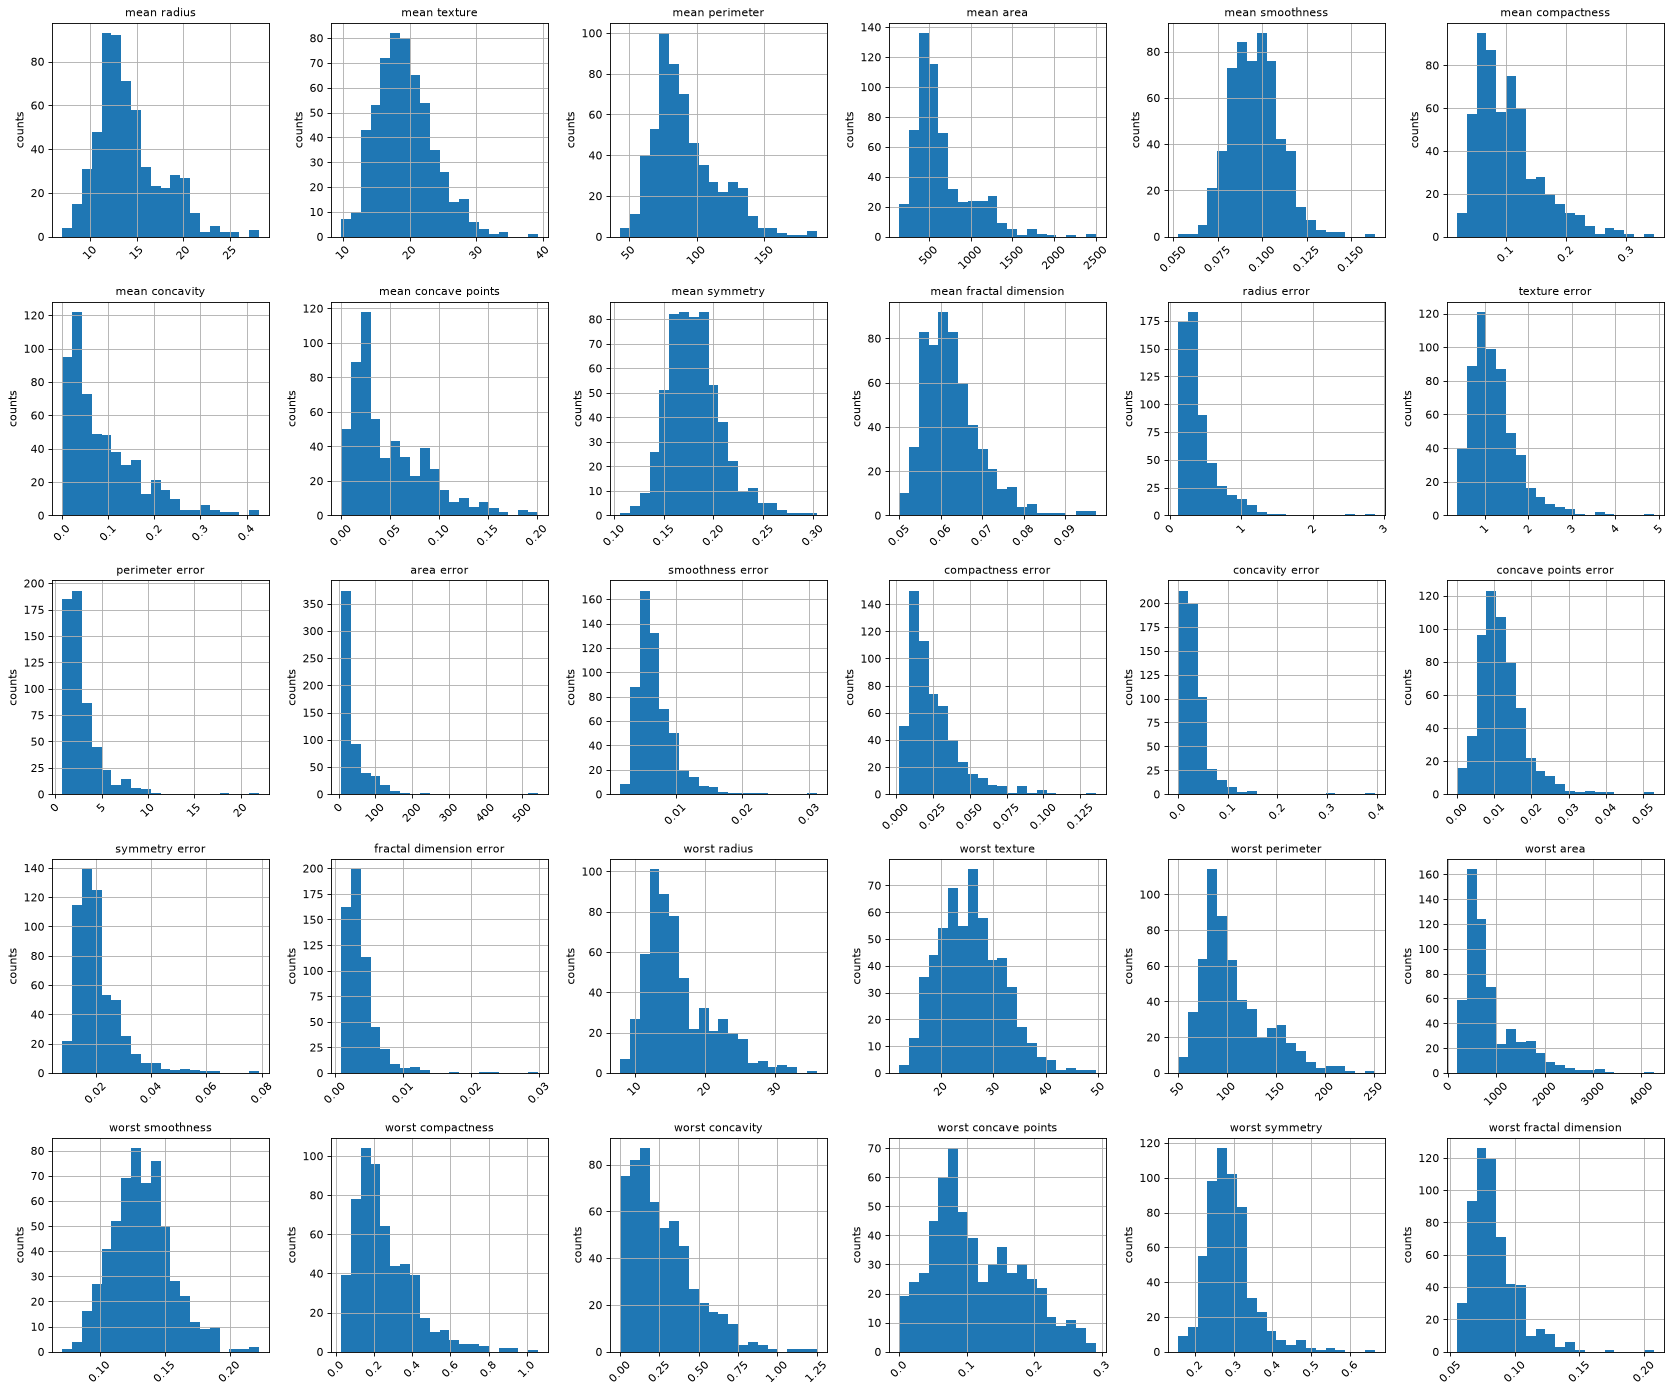

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plotPerColumnHistogram(df:pd.DataFrame, nGraphShown: int = 10):
    """
    Plots histograms for each column in the DataFrame.
    """
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1]]
    
    nCol = df.shape[1]
    if nCol == 0:
        print("No columns match the filtering criteria.")
        return

    total_plots = min(nCol, nGraphShown)

    nGraphPerRow = math.ceil(math.sqrt(total_plots))
    nGraphRow = math.ceil(total_plots / nGraphPerRow)
    
    plt.figure(figsize=(3.5 * nGraphPerRow, 3.5 * nGraphRow), dpi=80, facecolor='w', edgecolor='k')

    columnNames = list(df)
    for i in range(total_plots):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        
        if not np.issubdtype(type(columnDf.iloc[0]), np.number):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist(bins=20)
            
        plt.ylabel('counts')
        plt.xticks(rotation=45)
        plt.title(f'{columnNames[i]}', fontsize=10)
        
    plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=1.0)
    plt.show()
    
plotPerColumnHistogram(df, nGraphShown=30)


                         mean radius  mean texture  mean perimeter  mean area  \
mean radius                 1.000000      0.323782        0.997855   0.987357   
mean texture                0.323782      1.000000        0.329533   0.321086   
mean perimeter              0.997855      0.329533        1.000000   0.986507   
mean area                   0.987357      0.321086        0.986507   1.000000   
mean smoothness             0.170581     -0.023389        0.207278   0.177028   
mean compactness            0.506124      0.236702        0.556936   0.498502   
mean concavity              0.676764      0.302418        0.716136   0.685983   
mean concave points         0.822529      0.293464        0.850977   0.823269   
mean symmetry               0.147741      0.071401        0.183027   0.151293   
mean fractal dimension     -0.311631     -0.076437       -0.261477  -0.283110   
radius error                0.679090      0.275869        0.691765   0.732562   
texture error              -

<Axes: >

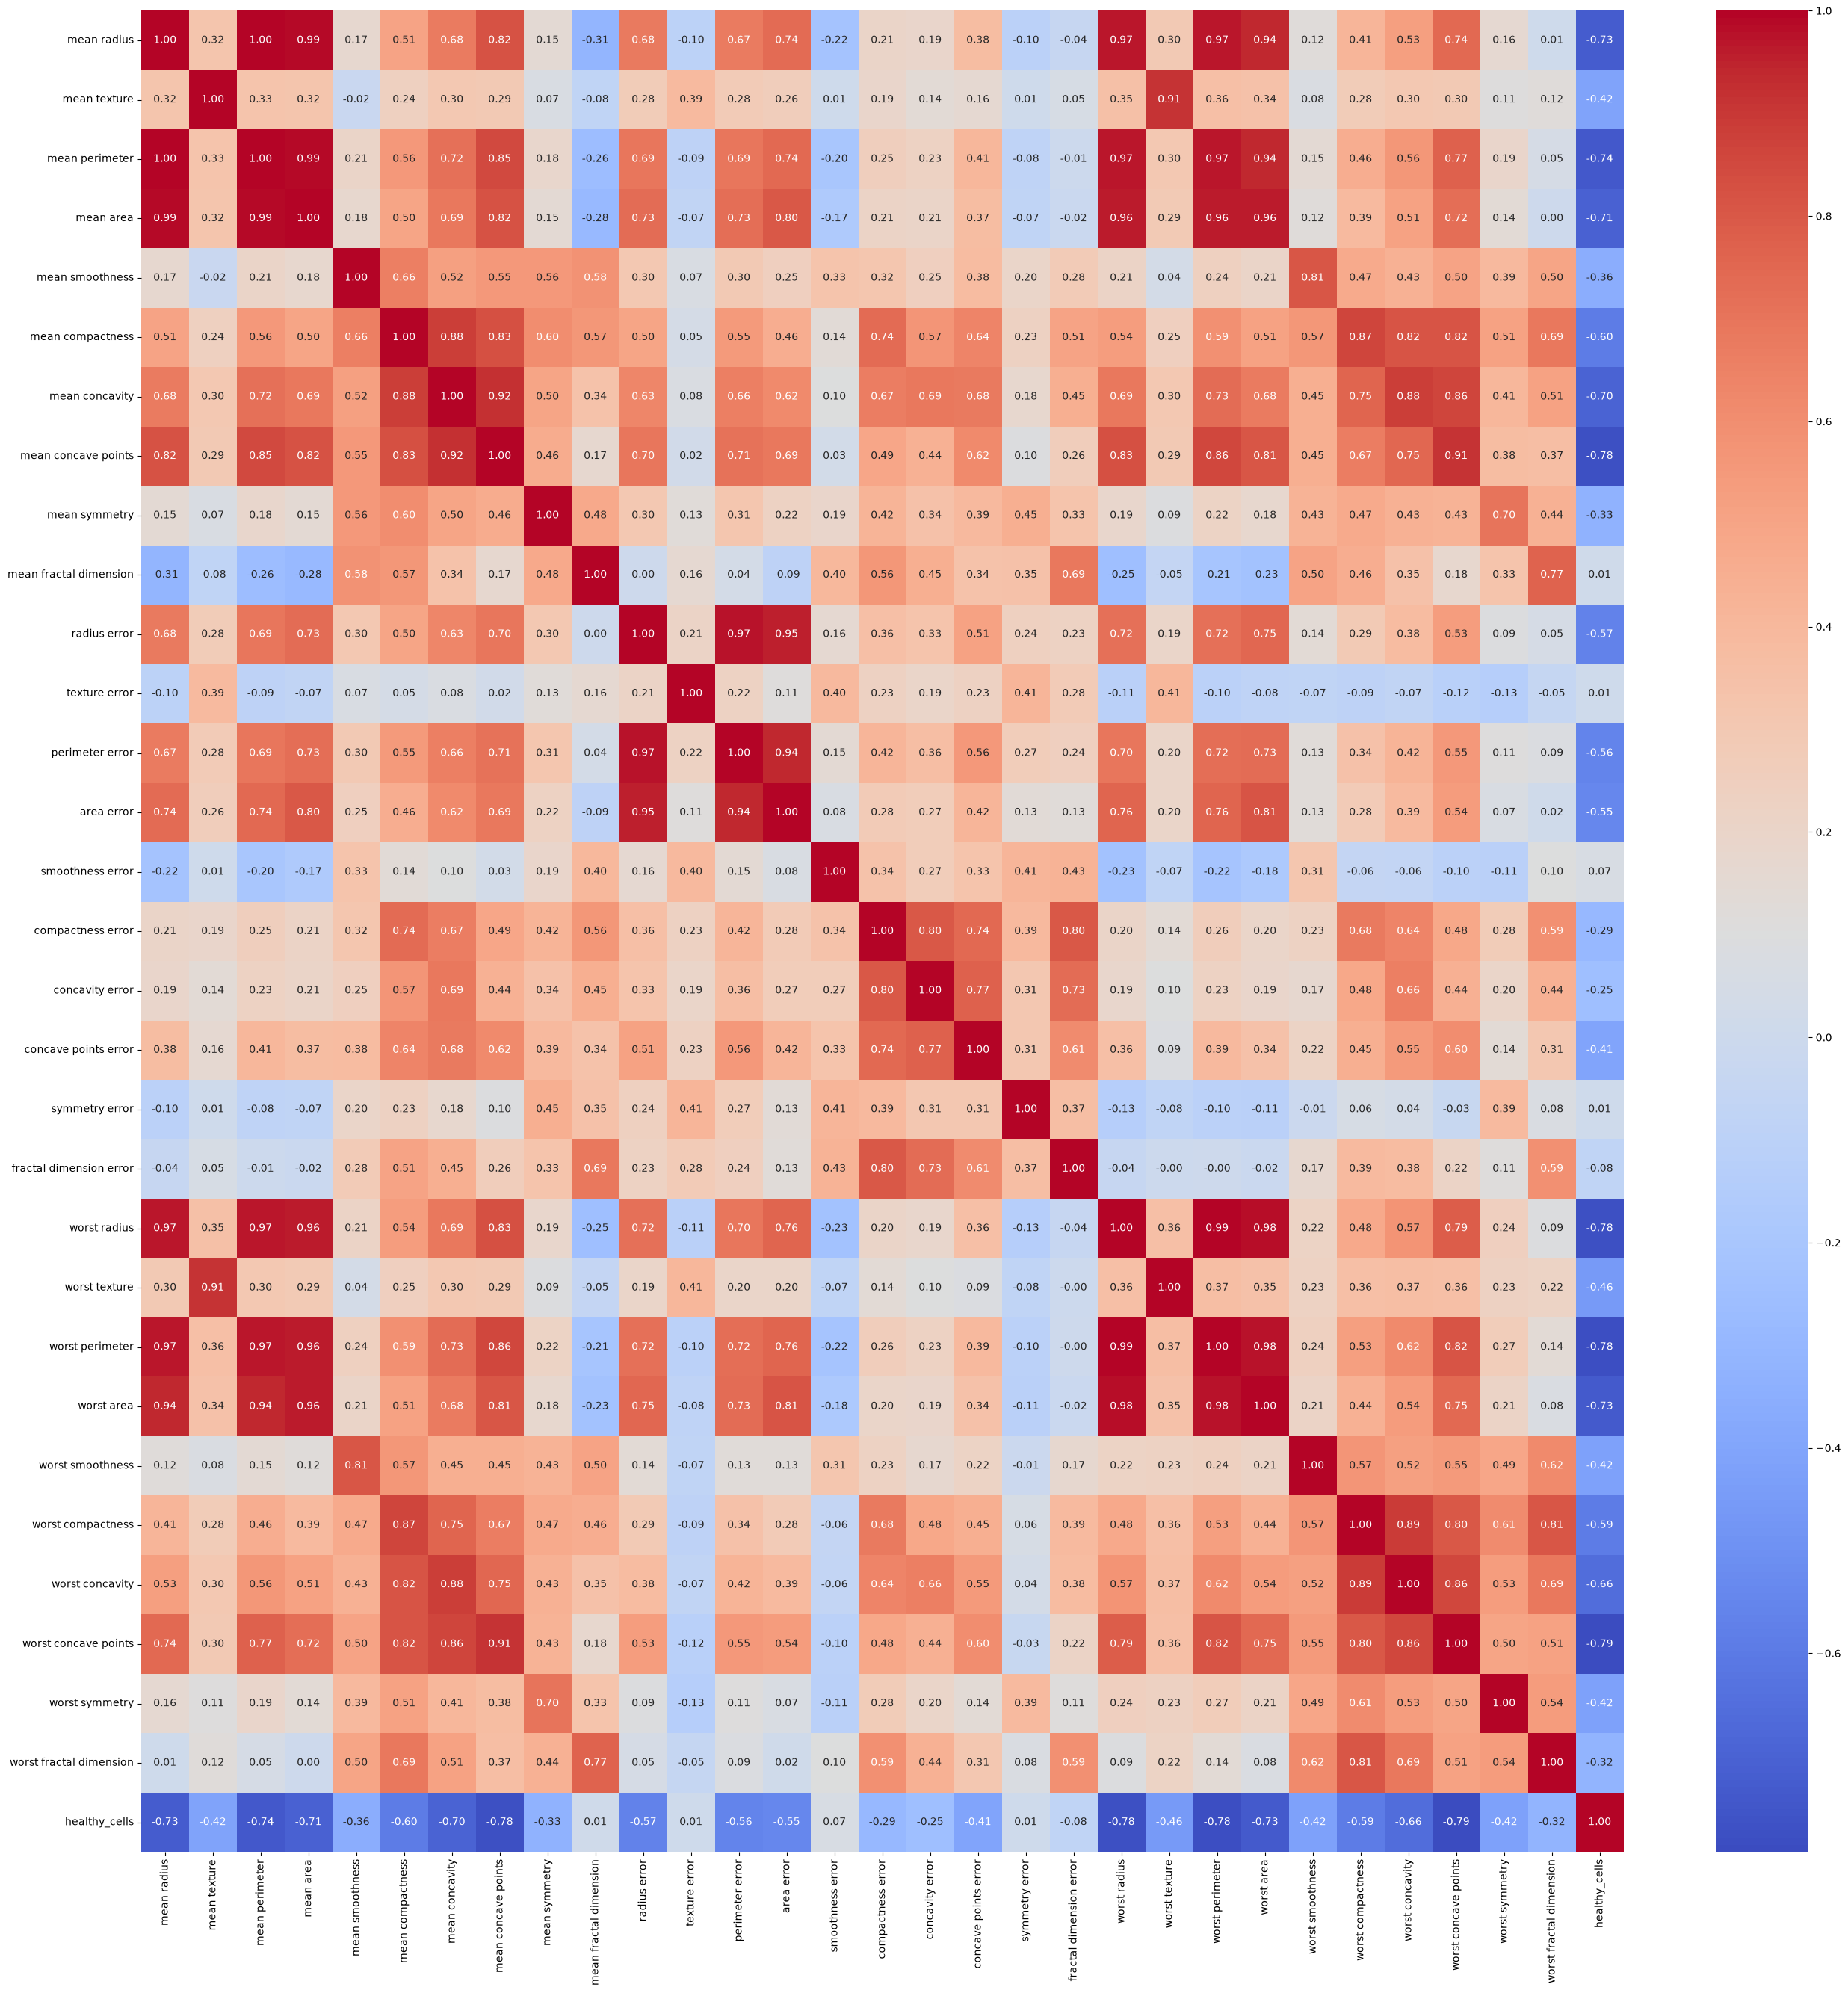

In [32]:
# correlation Matrix
import matplotlib.pyplot as plt
import seaborn as sns
correlation_matrix = df.corr()
print(correlation_matrix)
plt.figure(figsize=(32, 32))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

Mean Radius, Mean Area, and Mean Perimeter
exhibit extremely strong positive correlations
(approximately 0.98-0.99), indicating that they
are largely measuring the same underlying property:
nucleus size.

This suggests potential redundancy among these
variables. Future experiments may evaluate whether
Area and Perimeter can be removed with minimal loss
of predictive performance.

                         healthy_cells
mean radius                  -0.730029
mean texture                 -0.415185
mean perimeter               -0.742636
mean area                    -0.708984
mean smoothness              -0.358560
mean compactness             -0.596534
mean concavity               -0.696360
mean concave points          -0.776614
mean symmetry                -0.330499
mean fractal dimension        0.012838
radius error                 -0.567134
texture error                 0.008303
perimeter error              -0.556141
area error                   -0.548236
smoothness error              0.067016
compactness error            -0.292999
concavity error              -0.253730
concave points error         -0.408042
symmetry error                0.006522
fractal dimension error      -0.077972
worst radius                 -0.776454
worst texture                -0.456903
worst perimeter              -0.782914
worst area                   -0.733825
worst smoothness         

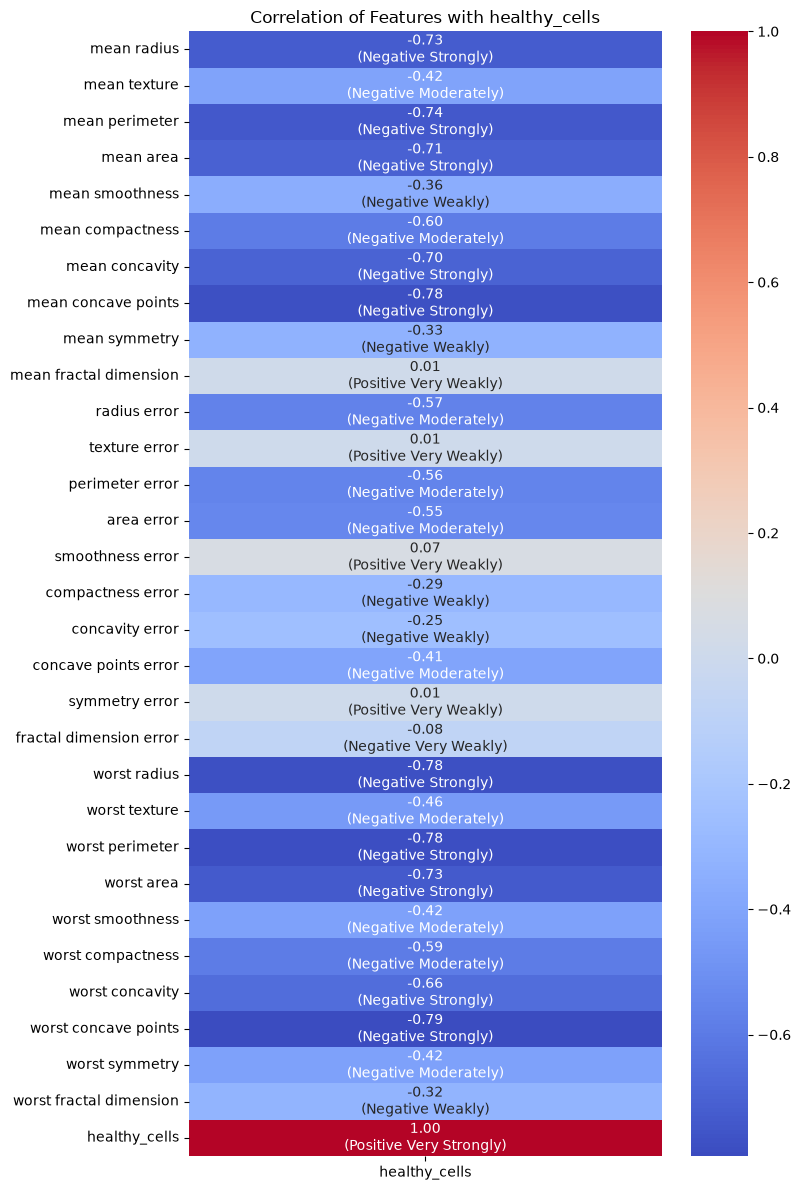

In [33]:
# Correlation of Features with Target Variable
# So this will help us to understand which features are more correlated with the target variable and 
# can be used for feature selection.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target_col = 'healthy_cells'
correlation_label = ["Very Weakly", "Weakly", "Moderately", "Strongly", "Very Strongly"]
correlation_ranges = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

def show_correlation(is_sorted=False, print_corr =False):
	corr_with_target = df.corr()[[target_col]].sort_values(by=target_col, ascending=False) if is_sorted else df.corr()[[target_col]]
	strengths = pd.cut(
		corr_with_target[target_col].abs(), 
		bins=correlation_ranges, 
		labels=correlation_label, 
		include_lowest=True
	)

	signs = np.where(corr_with_target[target_col] >= 0, "Positive", "Negative")
	if print_corr:
		print(corr_with_target)
	custom_annot = pd.DataFrame(
		[
			f"{val:.2f}\n({sign} {str(strength)})"
			for val, sign, strength in zip(corr_with_target[target_col], signs, strengths)
		],
		index=corr_with_target.index,
		columns=corr_with_target.columns
	)

	# Plot heatmap using custom annotations
	plt.figure(figsize=(8, 12))
	sns.heatmap(
		corr_with_target, 
		annot=custom_annot, 
		fmt="", 
		cmap="coolwarm", 
		cbar=True
	)
	plt.title(f"Correlation of Features with {target_col}")
	plt.tight_layout()
	plt.show()

show_correlation(is_sorted=False, print_corr=True)


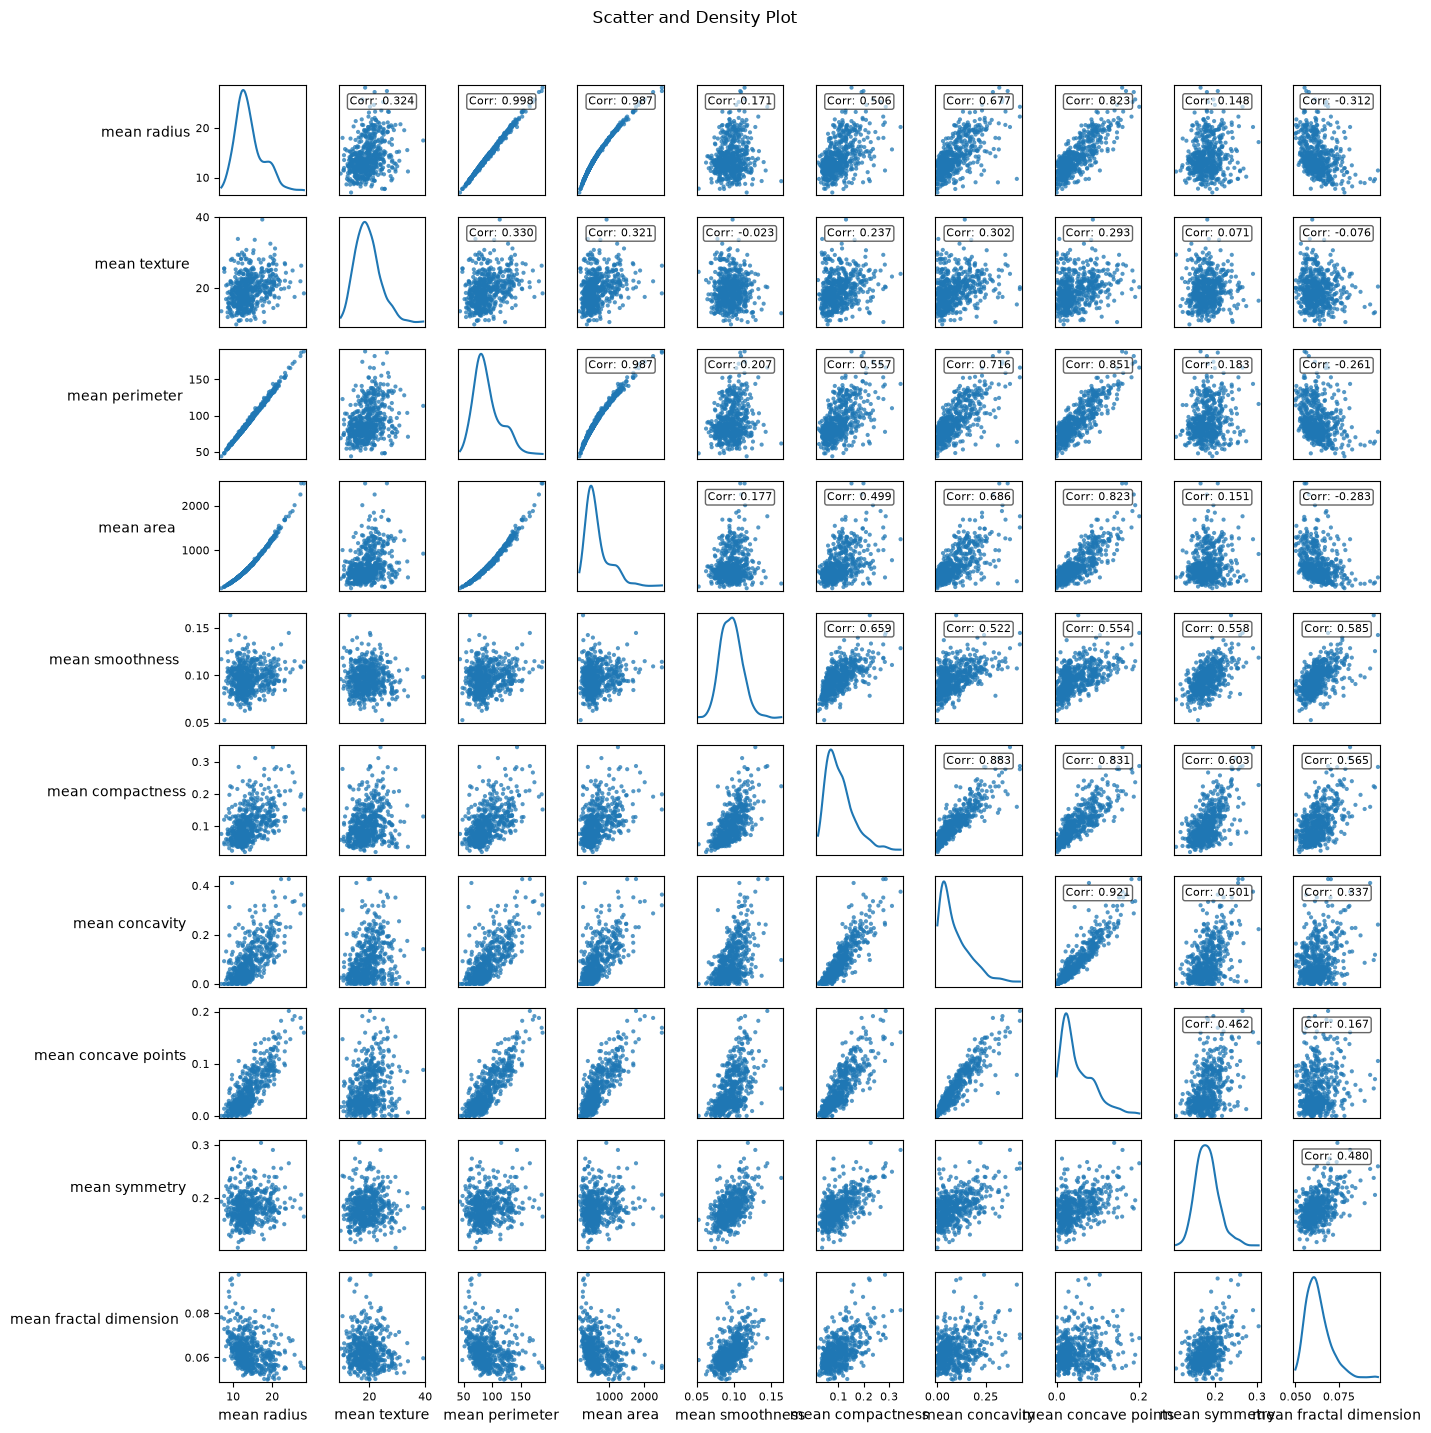

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plotScatterMatrix(df: pd.DataFrame, plotSize: float = 15, textSize: float = 10):

    df = df.select_dtypes(include=[np.number])
    df = df.dropna(axis='columns')
    df = df[[col for col in df if df[col].nunique() > 1]]
    
    columnNames = list(df)
    if len(columnNames) > 10:
        columnNames = columnNames[:10]
    df = df[columnNames]

    axes = pd.plotting.scatter_matrix(
        df, 
        alpha=0.75, 
        figsize=[plotSize, plotSize], 
        diagonal='kde'
    )

    for ax in axes.flatten():
        ax.xaxis.label.set_rotation(0)
        ax.yaxis.label.set_rotation(0)
        

        ax.xaxis.label.set_ha('center')
        ax.yaxis.label.set_ha('right')
        
        ax.tick_params(axis='x', labelrotation=0)
        ax.tick_params(axis='y', labelrotation=0)

    corrs = df.corr().values
    for i, j in zip(*np.triu_indices_from(axes, k=1)):
        axes[i, j].annotate(
            f'Corr: {corrs[i, j]:.3f}', 
            (0.5, 0.85), 
            xycoords='axes fraction', 
            ha='center', 
            va='center', 
            size=textSize,
            rotation=0,  
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6)
        )
        
    plt.suptitle('Scatter and Density Plot', y=1.02, fontsize=textSize + 4)
    plt.tight_layout()
    plt.show()

plotScatterMatrix(df, plotSize=14, textSize=8)